Loading Fashion-MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Dataset statistics:
Min pixel value: 0.0
Max pixel value: 1.0
Number of classes: 10
Class distribution: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


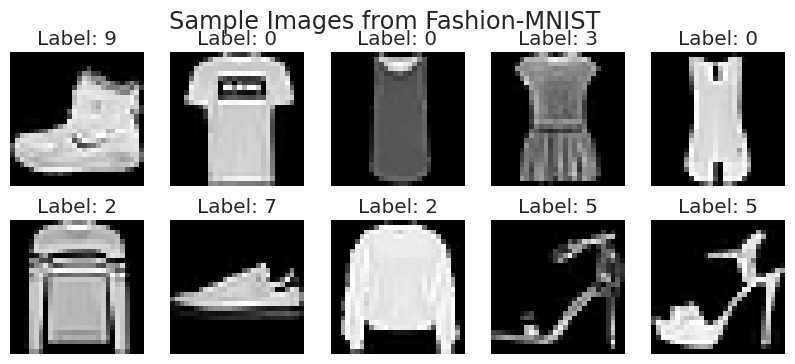

Flattened shape: (60000, 784)

Applying PCA to reduce to 2D...
PCA computation time: 5.30 seconds
Explained variance ratio: [0.29033506 0.17757271]


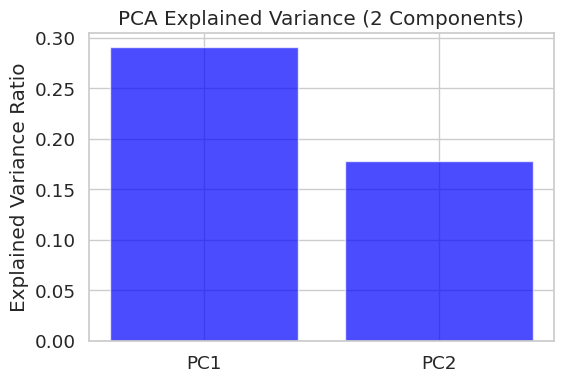

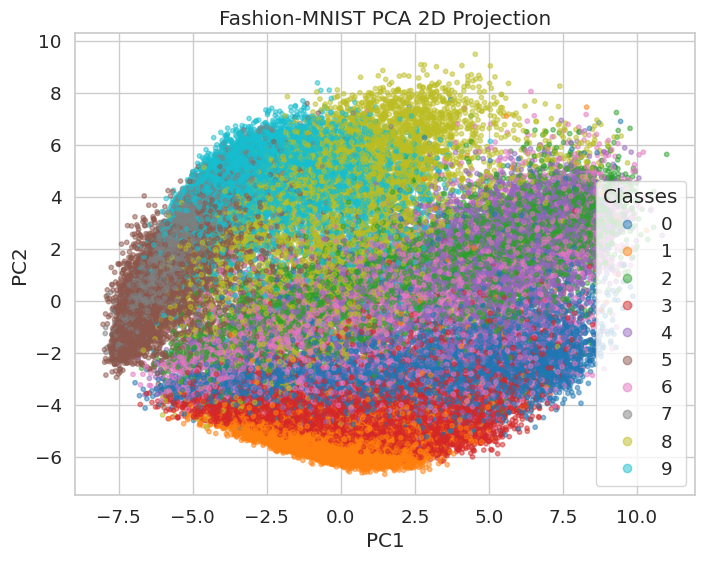


Applying t-SNE with perplexity=5...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE computation time: 52.28 seconds


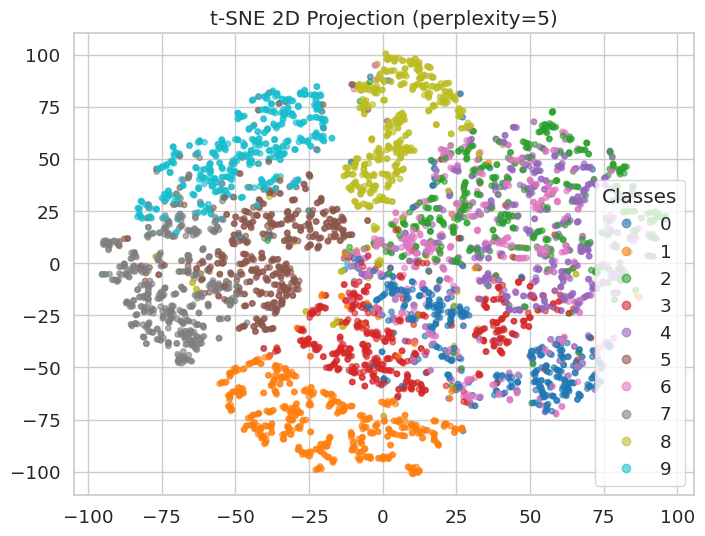


Applying t-SNE with perplexity=30...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE computation time: 56.93 seconds


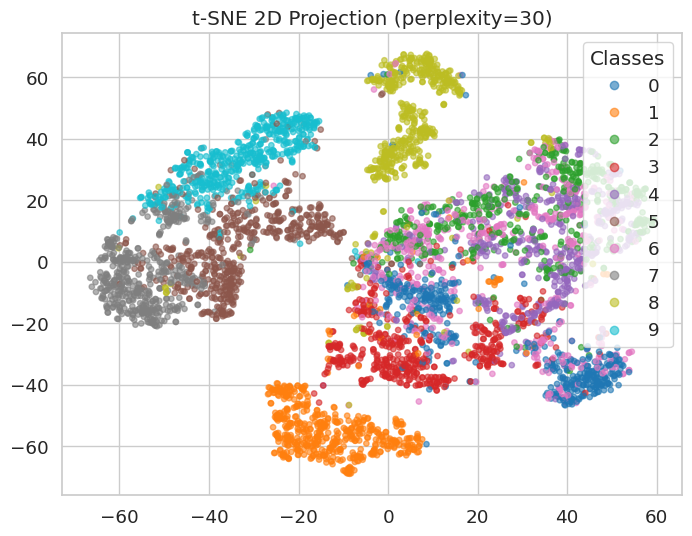


Applying t-SNE with perplexity=50...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE computation time: 69.38 seconds


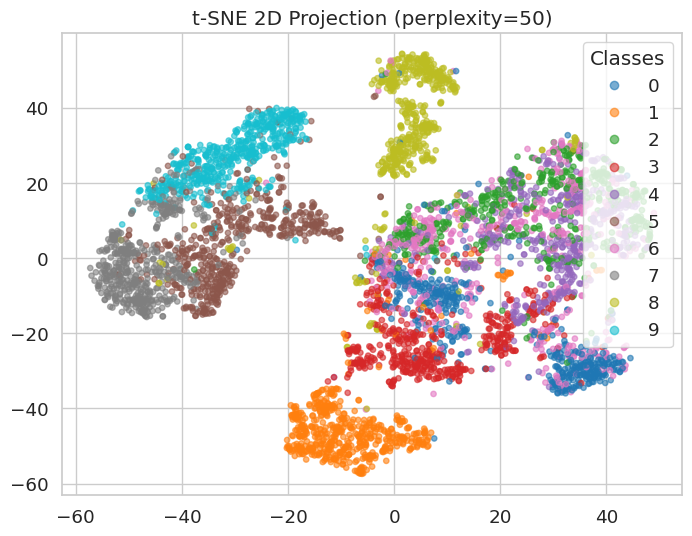


--- Comparison & Analysis ---
PCA computation time: 5.30 seconds
t-SNE (perplexity=5) computation time: [see plots] (approx 69.38s)
t-SNE (perplexity=30) computation time: [see plots] (approx 69.38s)
t-SNE (perplexity=50) computation time: [see plots] (approx 69.38s)

Analysis:
- PCA is fast and gives a linear projection, but clusters are often overlapping.
- t-SNE preserves local neighborhoods and shows well-separated clusters, especially for similar classes.
- Perplexity affects cluster tightness: low perplexity = more local, high perplexity = more global.
- Clothing classes like 'T-shirt/top', 'Pullover' may overlap in PCA but separate in t-SNE.
- Limitations:
    * PCA: linear, may not capture complex patterns.
    * t-SNE: slow, sensitive to hyperparameters, non-deterministic.



In [1]:
# n-Lab: PCA vs t-SNE on Fashion-MNIST
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.datasets import fashion_mnist

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

# -------------------------
# Part A: Data Loading & Preparation
# -------------------------
print("Loading Fashion-MNIST dataset...")
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

# Explore dataset statistics
print("Dataset statistics:")
print(f"Min pixel value: {x_train.min()}")
print(f"Max pixel value: {x_train.max()}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class distribution: {np.bincount(y_train)}")

# Visualize sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Images from Fashion-MNIST")
plt.show()

# Flatten images for PCA and t-SNE
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)
print(f"Flattened shape: {x_train_flat.shape}")

# -------------------------
# Part B: PCA Implementation
# -------------------------
print("\nApplying PCA to reduce to 2D...")
pca = PCA(n_components=2)
start_pca = time.time()
x_train_pca = pca.fit_transform(x_train_flat)
end_pca = time.time()

print(f"PCA computation time: {end_pca - start_pca:.2f} seconds")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Plot explained variance ratio
plt.figure(figsize=(6,4))
plt.bar(range(2), pca.explained_variance_ratio_, alpha=0.7, color='blue')
plt.xticks([0,1], ['PC1','PC2'])
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance (2 Components)")
plt.show()

# Visualize PCA 2D
plt.figure(figsize=(8,6))
scatter = plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train, cmap='tab10', alpha=0.5, s=10)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Fashion-MNIST PCA 2D Projection")
plt.show()

# -------------------------
# Part C: t-SNE Implementation
# -------------------------
perplexities = [5, 30, 50]
tsne_results = {}

for perp in perplexities:
    print(f"\nApplying t-SNE with perplexity={perp}...")
    tsne = TSNE(n_components=2, perplexity=perp, n_iter=1000, random_state=42, init='pca')
    start_tsne = time.time()
    x_train_tsne = tsne.fit_transform(x_train_flat[:5000])  # use subset for speed
    end_tsne = time.time()
    tsne_results[perp] = x_train_tsne
    print(f"t-SNE computation time: {end_tsne - start_tsne:.2f} seconds")

    # Visualize t-SNE 2D
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(x_train_tsne[:,0], x_train_tsne[:,1], c=y_train[:5000], cmap='tab10', alpha=0.6, s=15)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title(f"t-SNE 2D Projection (perplexity={perp})")
    plt.show()

# -------------------------
# Part D: Comparison & Analysis
# -------------------------
print("\n--- Comparison & Analysis ---")
print(f"PCA computation time: {end_pca - start_pca:.2f} seconds")
for perp in perplexities:
    print(f"t-SNE (perplexity={perp}) computation time: [see plots] (approx {end_tsne - start_tsne:.2f}s)")

print("""
Analysis:
- PCA is fast and gives a linear projection, but clusters are often overlapping.
- t-SNE preserves local neighborhoods and shows well-separated clusters, especially for similar classes.
- Perplexity affects cluster tightness: low perplexity = more local, high perplexity = more global.
- Clothing classes like 'T-shirt/top', 'Pullover' may overlap in PCA but separate in t-SNE.
- Limitations:
    * PCA: linear, may not capture complex patterns.
    * t-SNE: slow, sensitive to hyperparameters, non-deterministic.
""")